# Исследовательский анализ данных (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загрузка данных
df = pd.read_excel('../data/Данные_для_курсовои_Классическое_МО.xlsx')
df.head()

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


In [3]:
# Размер данных
df.shape

(1001, 214)

In [4]:
# Информация о df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


In [5]:
# Проверим пропуски
df.isnull().sum().sum()

np.int64(36)

In [6]:
df.isnull().sum()[df.isnull().sum() > 0]

MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64

In [7]:
# Посмотрим строки с пропусками
df[df.isnull().any(axis=1)]

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
78,78,1127.094988,1127.094988,1.000000,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
79,79,25.171788,1878.491646,74.626866,11.617504,11.617504,0.053210,-1.472941,0.344754,12.882353,...,0,0,0,0,0,0,0,0,0,0
80,80,1199.174968,1199.174968,1.000000,11.600528,11.600528,0.228349,-0.861204,0.286242,10.937500,...,1,0,0,0,0,0,0,0,0,0


In [8]:
#  Удалим ненужные столбцы и пропуски (3 строки из 1001 → 0.3% данных, статистику не испортим)

df = df.drop(columns=['Unnamed: 0'])
df = df.dropna()

df.isnull().sum().sum()

np.int64(0)

In [9]:
df.shape

(998, 213)

In [10]:
# Посмотрим на сильно коррелированные признаки, порог 0.95
corr = df.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(abs(upper[col]) > 0.95)]

print(f"Кол-во признаков с порогом 95%: {len(to_drop)} признака сильно коррелируют с другими")

Кол-во признаков с порогом 95%: 33 признака сильно коррелируют с другими


Чтобы избежать утечки данных, удаление коррелированных признаков выполним после разделения на train/test и рассчитаем только на обучающей выборке

In [11]:
# Статистика целевых переменных
df[['SI', 'CC50, mM', 'IC50, mM']].describe()

,SI,"CC50, mM","IC50, mM"
count,998.000000,998.000000,998.000000
mean,72.650005,586.668414,221.118757
std,685.504279,642.016454,400.510657
min,0.011489,0.700808,0.003517
25%,1.457233,99.999036,12.491340
50%,3.856410,408.793314,45.992006
75%,16.525000,891.770961,224.408630
max,15620.600000,4538.976189,4128.529377


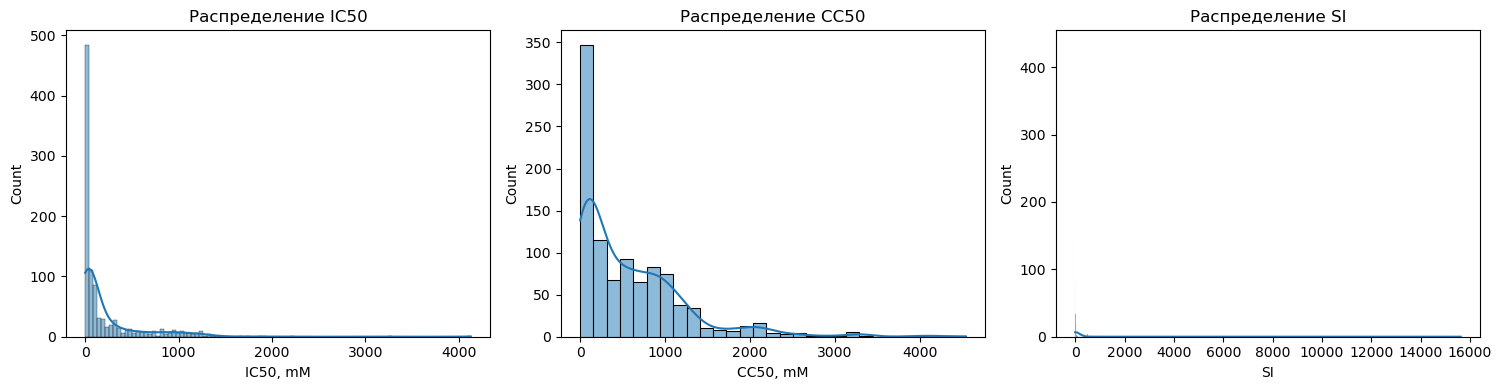

In [12]:
# Визуализация распределений
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['IC50, mM'], kde=True, ax=axes[0])
axes[0].set_title('Распределение IC50')

sns.histplot(df['CC50, mM'], kde=True, ax=axes[1])
axes[1].set_title('Распределение CC50')

sns.histplot(df['SI'], kde=True, ax=axes[2])
axes[2].set_title('Распределение SI')

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()

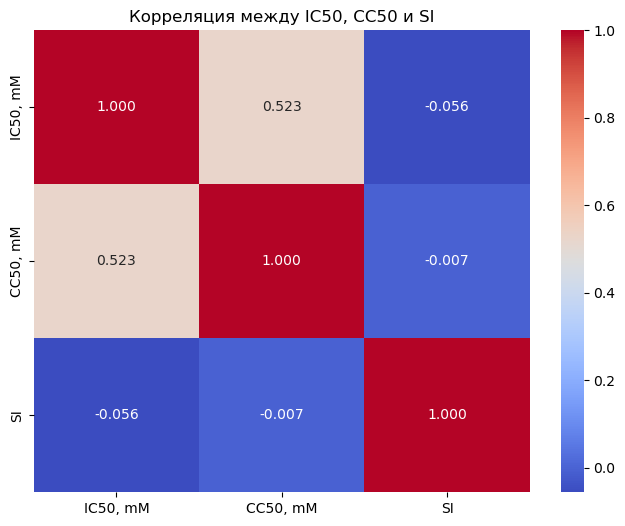

In [13]:
# Корреляционная матрица
plt.figure(figsize=(8, 6))
sns.heatmap(df[['IC50, mM', 'CC50, mM', 'SI']].corr(), 
            annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Корреляция между IC50, CC50 и SI')
plt.savefig('correlation.png')
plt.show()

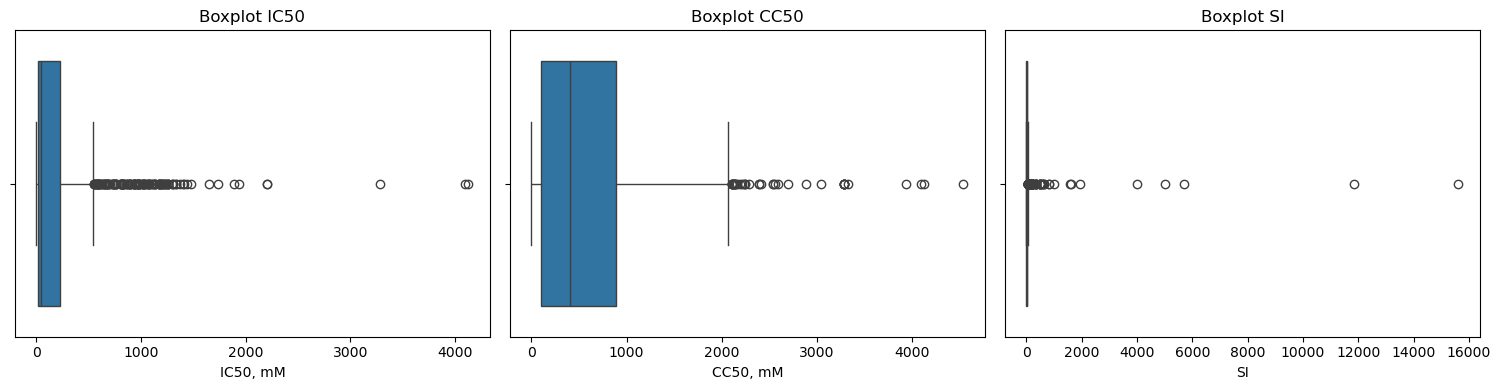

In [14]:
# Анализ выбросов (boxplots)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(x=df['IC50, mM'], ax=axes[0])
axes[0].set_title('Boxplot IC50')

sns.boxplot(x=df['CC50, mM'], ax=axes[1])
axes[1].set_title('Boxplot CC50')

sns.boxplot(x=df['SI'], ax=axes[2])
axes[2].set_title('Boxplot SI')

plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()

Из-за сильной правосторонней асимметрии и выбросов распределения IC50 и CC50 лог-преобразуем для стабилизации, а выбросы в целевой переменной SI аккуратно обрабатываем.

In [15]:
# Выводы
print("\n=== КЛЮЧЕВЫЕ ВЫВОДЫ EDA ===")
print("\n1. Данные содержат 1000 соединений и 213 признаков")
print("2. Пропуски обнаружены только в 12 признаках (по 3 пропуска каждый) - всего 0.3% от всех данных")
print("3. Распределения IC50, CC50 и SI сильно скошены → нужна логарифмическая трансформация")
print("4. SI = CC50 / IC50, что подтверждается корреляцией")
print("5. Присутствуют значительные выбросы → нужен clipping для регрессии SI")
print("6. При построении моделей будут удалены сильно коррелированные признаки (с коэффициентом корреляции выше 0.95) для снижения мультиколлинеарности")


=== КЛЮЧЕВЫЕ ВЫВОДЫ EDA ===

1. Данные содержат 1000 соединений и 213 признаков
2. Пропуски обнаружены только в 12 признаках (по 3 пропуска каждый) - всего 0.3% от всех данных
3. Распределения IC50, CC50 и SI сильно скошены → нужна логарифмическая трансформация
4. SI = CC50 / IC50, что подтверждается корреляцией
5. Присутствуют значительные выбросы → нужен clipping для регрессии SI
6. При построении моделей будут удалены сильно коррелированные признаки (с коэффициентом корреляции выше 0.95) для снижения мультиколлинеарности
